In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('titanic.csv')

In [3]:
print(f"Dataset dimensions: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics for numerical columns:")
print(df.describe())

print("\nMissing values in each column:")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

print(f"\nDistribution of target variable 'Survived':")
print(df['Survived'].value_counts())
print(f"\nSurvival rate: {df['Survived'].mean():.2%}")


Dataset dimensions: (891, 12)
Number of rows: 891
Number of columns: 12

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Summary statistics for numerical columns:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    

In [4]:
df_clean = df.copy()

print("Initial dataframe shape:", df_clean.shape)

print("\nAnalyzing columns for potential dropping:")
high_missing_threshold = 70

for column in df_clean.columns:
    missing_pct = (df_clean[column].isnull().sum() / len(df_clean)) * 100
    if missing_pct > high_missing_threshold:
        df_clean = df_clean.drop(column, axis=1)

if 'Cabin' in df_clean.columns:
    df_clean = df_clean.drop('Cabin', axis=1)

print(f"Dataframe shape after dropping high-missing columns: {df_clean.shape}")

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    if df_clean[col].isnull().any():
        missing_count = df_clean[col].isnull().sum()
        if col == 'Age':
            median_age = df_clean['Age'].median()
            df_clean['Age'].fillna(median_age, inplace=True)
        elif col == 'Fare':
            median_fare = df_clean['Fare'].median()
            df_clean['Fare'].fillna(median_fare, inplace=True)

categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df_clean[col].isnull().any():
        missing_count = df_clean[col].isnull().sum()
        if missing_count <= 2:
            mode_value = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_value, inplace=True)
        else:
            missing_pct = (missing_count / len(df_clean)) * 100

if 'Embarked' in df_clean.columns and df_clean['Embarked'].isnull().any():
    missing_count = df_clean['Embarked'].isnull().sum()
    mode_embarked = df_clean['Embarked'].mode()[0]
    df_clean['Embarked'].fillna(mode_embarked, inplace=True)

remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    pass
else:
    if len(remaining_missing) > 0:
        initial_rows = len(df_clean)
        df_clean = df_clean.dropna()
        dropped_rows = initial_rows - len(df_clean)

print(f"\nFinal dataframe shape after missing value handling: {df_clean.shape}")

columns_to_drop = ['PassengerId', 'Name', 'Ticket']

existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]


df_clean = df_clean.drop(existing_columns_to_drop, axis=1, errors='ignore')

print(f"\nRemaining columns: {list(df_clean.columns)}")
print(f"Data shape: {df_clean.shape}")

print("\nCreating new features:")
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                              bins=[0, 12, 18, 35, 60, 100],
                              labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
df_clean['FarePerPerson'] = df_clean['Fare'] / df_clean['FamilySize']

categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
numerical_cols = [col for col in numerical_cols if col != 'Survived']

print(f"Numerical columns: {numerical_cols}")

df_encoded = df_clean.copy()

for col in categorical_cols:
    if col in df_encoded.columns:
        if df_encoded[col].nunique() <= 5:
            print(f"  - One-hot encoding '{col}' ({df_encoded[col].nunique()} unique values)")
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            df_encoded = pd.concat([df_encoded.drop(col, axis=1), dummies], axis=1)
        else:
            print(f"  - Label encoding '{col}' ({df_encoded[col].nunique()} unique values)")
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

if 'Survived' not in df_encoded.columns:
    df_encoded['Survived'] = df_clean['Survived']

print(f"\nShape after encoding: {df_encoded.shape}")
print(f"Number of features: {df_encoded.shape[1] - 1}")

X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print(f"Number of features: {X.shape[1]}")
print(f"First few features: {list(X.columns)[:10]}...")

Initial dataframe shape: (891, 12)

Analyzing columns for potential dropping:
Dataframe shape after dropping high-missing columns: (891, 11)

Final dataframe shape after missing value handling: (712, 11)

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Data shape: (712, 8)

Creating new features:
Numerical columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
  - One-hot encoding 'Sex' (2 unique values)
  - One-hot encoding 'Embarked' (3 unique values)
  - One-hot encoding 'AgeGroup' (5 unique values)

Shape after encoding: (712, 16)
Number of features: 15

Final feature matrix shape: (712, 15)
Target vector shape: (712,)
Number of features: 15
First few features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_male', 'Embarked_Q']...


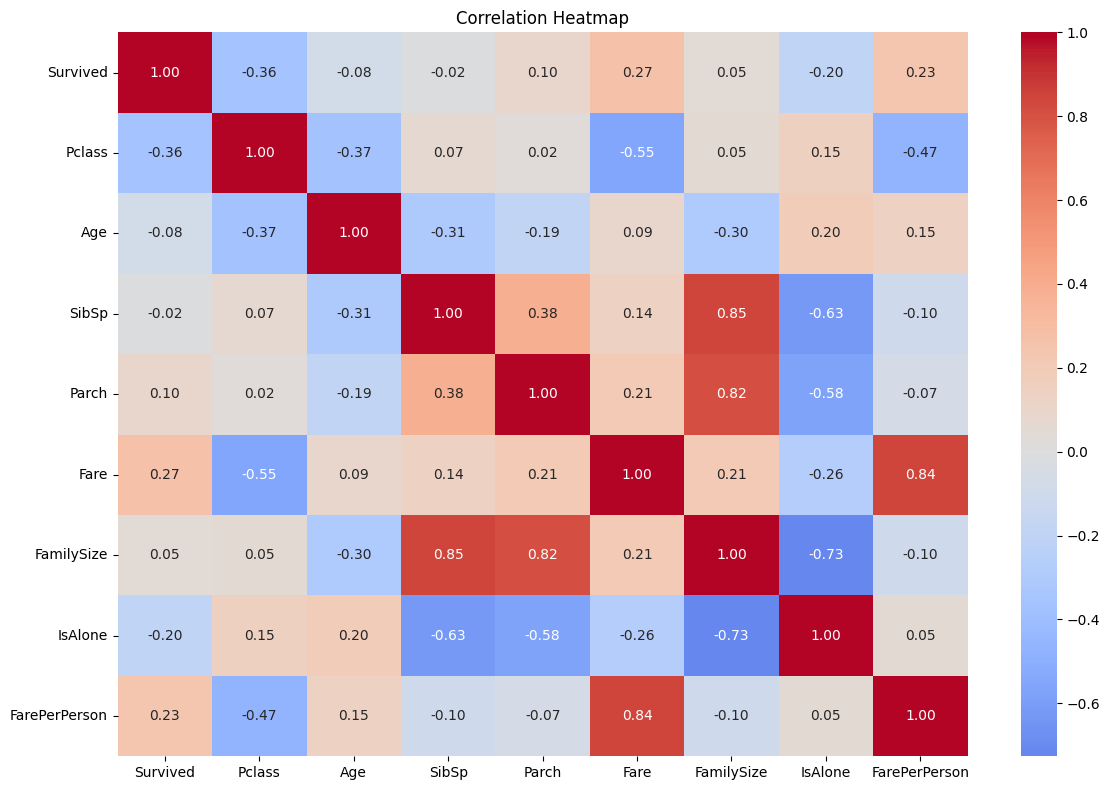

In [5]:
plt.figure(figsize=(12, 8))
numerical_for_corr = df_encoded.select_dtypes(include=[np.number])
correlation_matrix = numerical_for_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Testing target distribution:\n{y_test.value_counts()}")

Training set size: (569, 15)
Testing set size: (143, 15)
Training target distribution:
Survived
0    339
1    230
Name: count, dtype: int64
Testing target distribution:
Survived
0    85
1    58
Name: count, dtype: int64


In [7]:
scale_columns = []
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        if X[col].nunique() > 2:
            scale_columns.append(col)

print(f"Columns to scale (continuous features): {scale_columns}")
print(f"Columns NOT to scale (binary/categorical): {[col for col in X.columns if col not in scale_columns]}")

scaler = StandardScaler()

if scale_columns:
    X_train_scaled = X_train.copy()
    X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])
    X_test_scaled = X_test.copy()
    X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

    print("Continuous features have been standardized (scaled)")
else:
    print("No continuous features to scale")
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

Columns to scale (continuous features): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson']
Columns NOT to scale (binary/categorical): ['IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior']
Continuous features have been standardized (scaled)


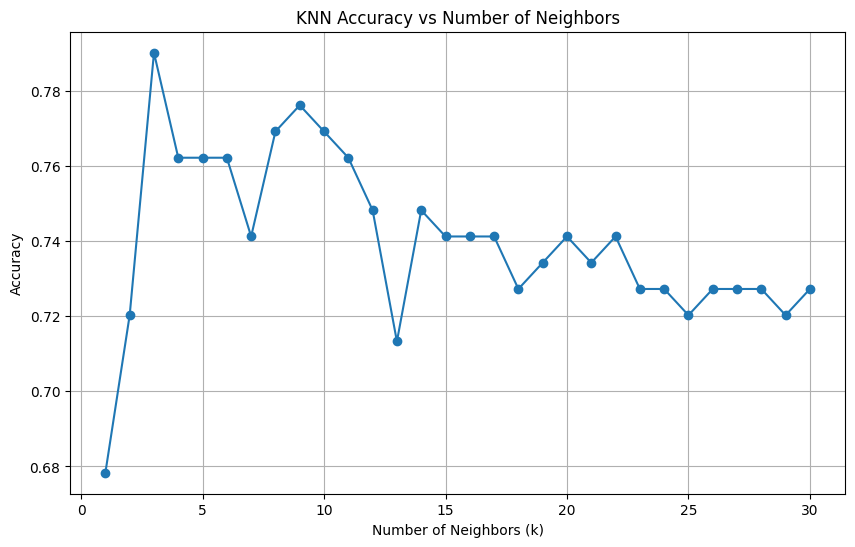

Best k from simple test: 3 with accuracy: 0.7902

KNN Model Performance (k=3):
Accuracy: 0.7902
Recall: 0.7586
Precision: 0.7333


In [8]:
accuracy_scores = []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.grid(True)
plt.show()

best_k_simple = k_values[np.argmax(accuracy_scores)]
print(f"Best k from simple test: {best_k_simple} with accuracy: {max(accuracy_scores):.4f}")

knn_best_simple = KNeighborsClassifier(n_neighbors=best_k_simple)
knn_best_simple.fit(X_train_scaled, y_train)
y_pred_knn = knn_best_simple.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)

print(f"\nKNN Model Performance (k={best_k_simple}):")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")

In [9]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7856


Test Accuracy: 0.7692
Recall: 0.7241
Precision: 0.7119

Confusion Matrix:
[[68 17]
 [16 42]]


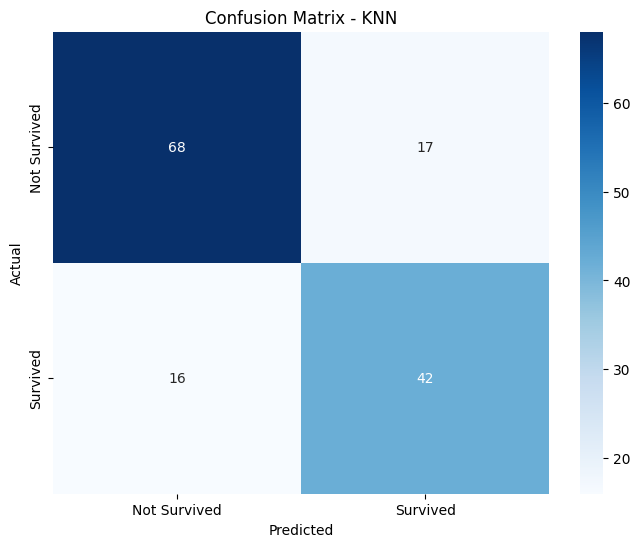


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.80      0.80        85
    Survived       0.71      0.72      0.72        58

    accuracy                           0.77       143
   macro avg       0.76      0.76      0.76       143
weighted avg       0.77      0.77      0.77       143



In [10]:
y_pred_best = best_knn.predict(X_test_scaled)

accuracy_best = accuracy_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)

print(f"Test Accuracy: {accuracy_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"Precision: {precision_best:.4f}")

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred_best)
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Survived', 'Survived']))

In [11]:
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=3,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

print(f"Best Logistic Regression parameters: {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

print("\nProbabilities for first 5 test samples (Logistic Regression):")
probabilities_lr = best_lr.predict_proba(X_test_scaled)[:5]
for i, probs in enumerate(probabilities_lr):
    print(f"Sample {i + 1}: Not Survived={probs[0]:.3f}, Survived={probs[1]:.3f}")

Best Logistic Regression parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best CV accuracy: 0.7978
Test Accuracy: 0.8112

Probabilities for first 5 test samples (Logistic Regression):
Sample 1: Not Survived=0.349, Survived=0.651
Sample 2: Not Survived=0.715, Survived=0.285
Sample 3: Not Survived=0.797, Survived=0.203
Sample 4: Not Survived=0.092, Survived=0.908
Sample 5: Not Survived=0.757, Survived=0.243


In [12]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=3,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"Best Decision Tree parameters: {dt_grid.best_params_}")
print(f"Best CV accuracy: {dt_grid.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("\nProbabilities for first 5 test samples (Decision Tree):")
probabilities_dt = best_dt.predict_proba(X_test)[:5]
for i, probs in enumerate(probabilities_dt):
    print(f"Sample {i + 1}: Not Survived={probs[0]:.3f}, Survived={probs[1]:.3f}")

Best Decision Tree parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV accuracy: 0.8120
Test Accuracy: 0.7902

Probabilities for first 5 test samples (Decision Tree):
Sample 1: Not Survived=0.000, Survived=1.000
Sample 2: Not Survived=0.800, Survived=0.200
Sample 3: Not Survived=1.000, Survived=0.000
Sample 4: Not Survived=1.000, Survived=0.000
Sample 5: Not Survived=1.000, Survived=0.000


Model                Accuracy   Recall     Precision 
--------------------------------------------------
KNN                  0.7692      0.7241      0.7119
Logistic Regression  0.8112      0.7414      0.7818
Decision Tree        0.7902      0.6552      0.7917

Best model: Logistic Regression with accuracy: 0.8112

Top 10 most important features (Decision Tree):
                 feature  importance
8               Sex_male    0.312522
1                    Age    0.179357
7          FarePerPerson    0.173452
0                 Pclass    0.121007
4                   Fare    0.095486
2                  SibSp    0.057070
5             FamilySize    0.026719
12  AgeGroup_Young Adult    0.011326
6                IsAlone    0.009818
11         AgeGroup_Teen    0.008992


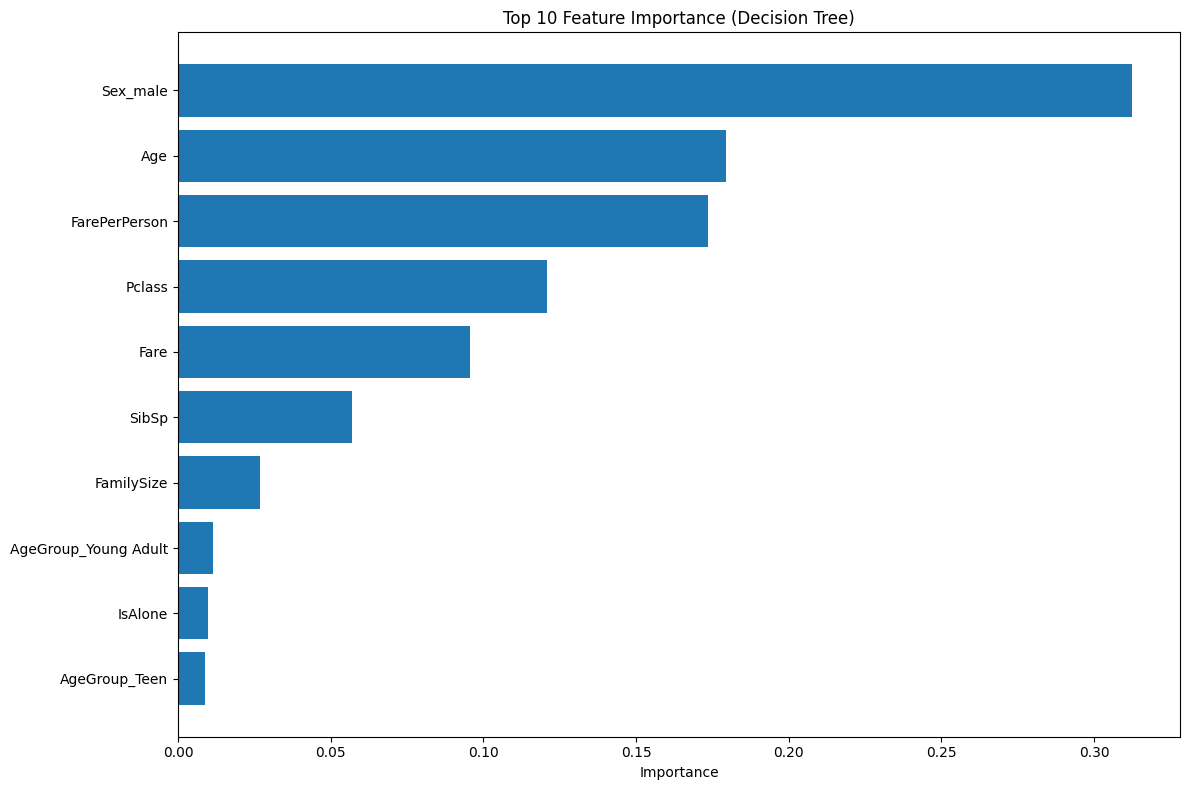

In [13]:
models = {
    'KNN': (accuracy_best, best_knn),
    'Logistic Regression': (accuracy_score(y_test, y_pred_lr), best_lr),
    'Decision Tree': (accuracy_score(y_test, y_pred_dt), best_dt)
}

print(f"{'Model':<20} {'Accuracy':<10} {'Recall':<10} {'Precision':<10}")
print("-" * 50)
for model_name, (acc, model) in models.items():
    y_pred = model.predict(X_test_scaled if model_name != 'Decision Tree' else X_test)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"{model_name:<20} {acc:.4f}      {recall:.4f}      {precision:.4f}")

best_model_name = max(models.items(), key=lambda x: x[1][0])[0]
best_model_accuracy = models[best_model_name][0]
print(f"\nBest model: {best_model_name} with accuracy: {best_model_accuracy:.4f}")

if hasattr(best_dt, 'feature_importances_'):
    print("\nTop 10 most important features (Decision Tree):")
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_dt.feature_importances_
    }).sort_values('importance', ascending=False)

    print(feature_importance.head(10))
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['feature'].head(10), feature_importance['importance'].head(10))
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importance (Decision Tree)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Best Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Accuracy: 0.7692
Recall: 0.7241
Precision: 0.7119
F1-Score: 0.7179
Confusion Matrix:
[[68 17]
 [16 42]]
Best Parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best CV Score: 0.8067
Test Accuracy: 0.8112
Recall: 0.7414
Precision: 0.7818
F1-Score: 0.7611
Confusion Matrix:
[[73 12]
 [15 43]]

Probabilities for first 5 test samples (Logistic Regression):
  Sample 1: Not Survived=0.349, Survived=0.651
  Sample 2: Not Survived=0.715, Survived=0.285
  Sample 3: Not Survived=0.797, Survived=0.203
  Sample 4: Not Survived=0.092, Survived=0.908
  Sample 5: Not Survived=0.757, Survived=0.243
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.8207
Test Accuracy: 0.8042
Recall: 0.7586
Precision: 0.7586
F1-Score: 0.7586
Confusion Matrix:
[[71 1

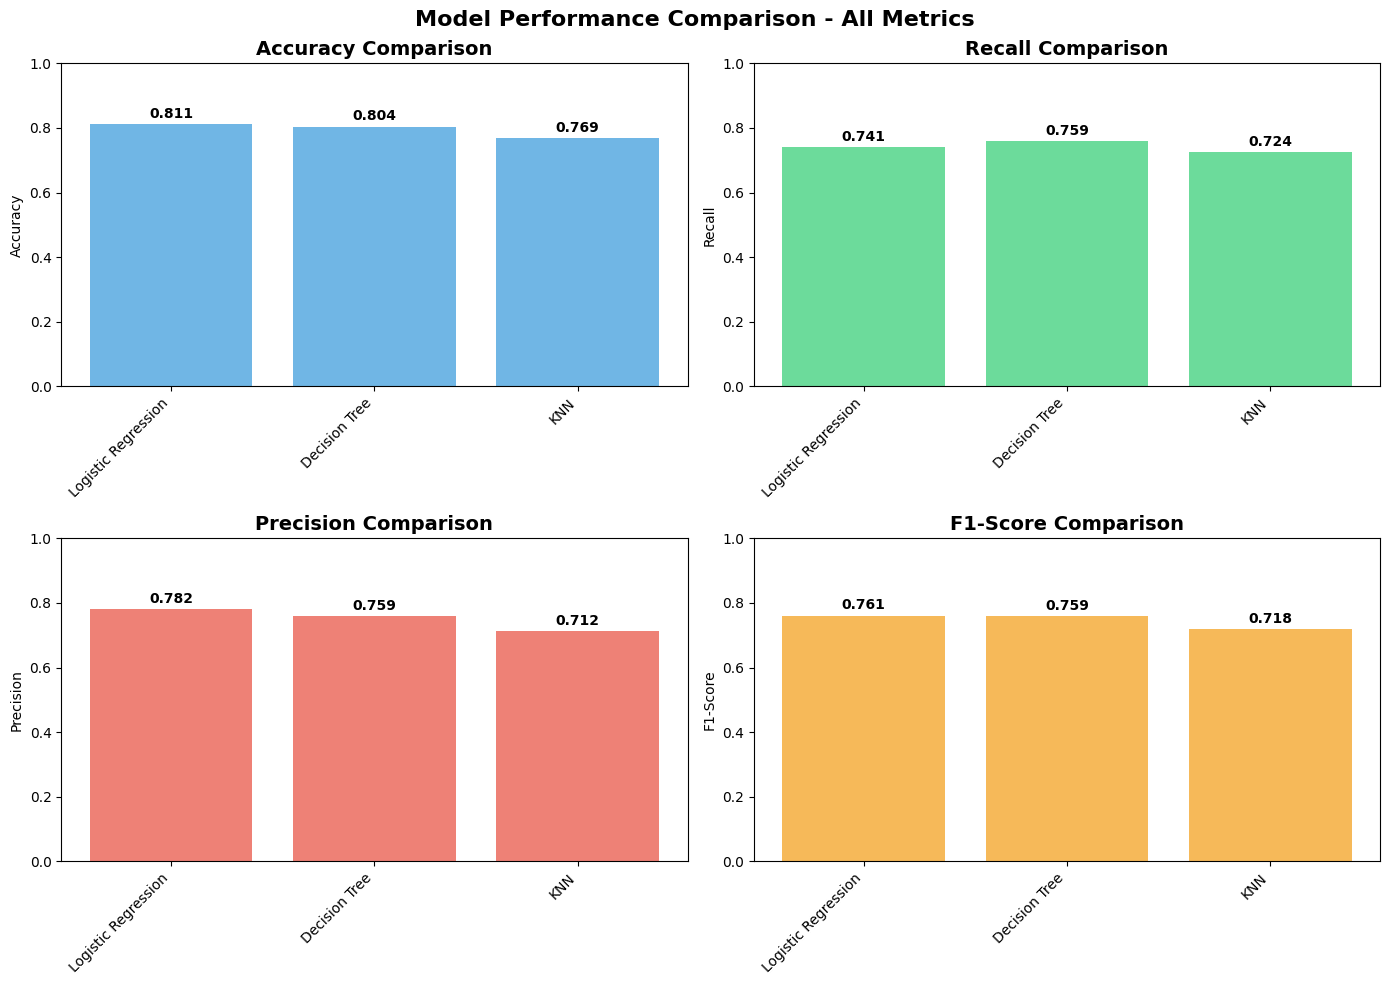

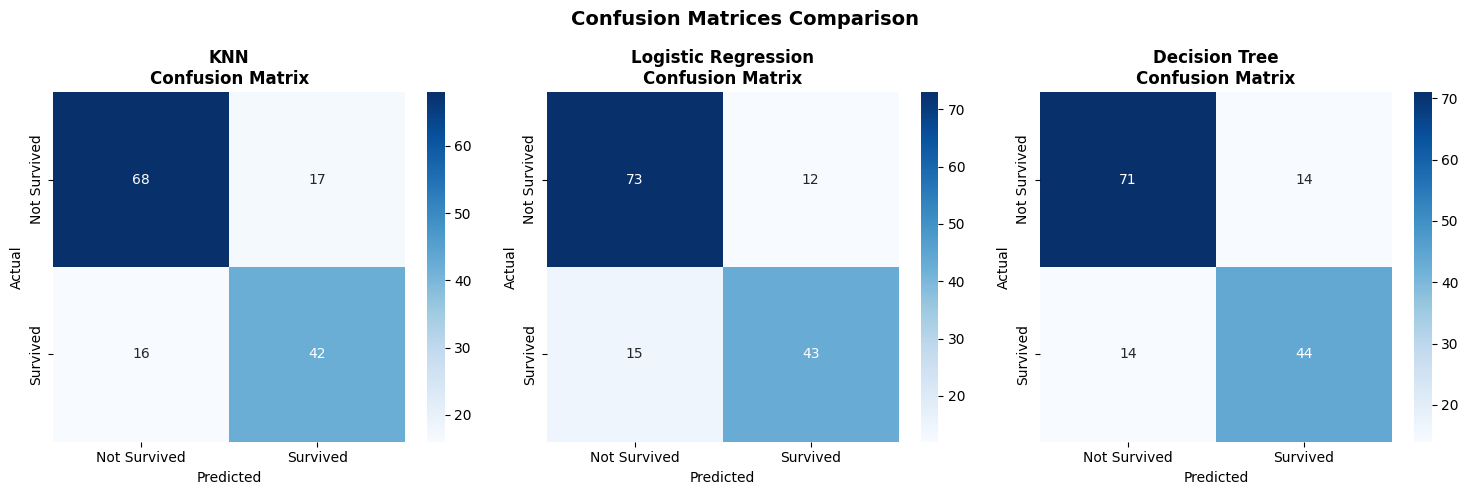

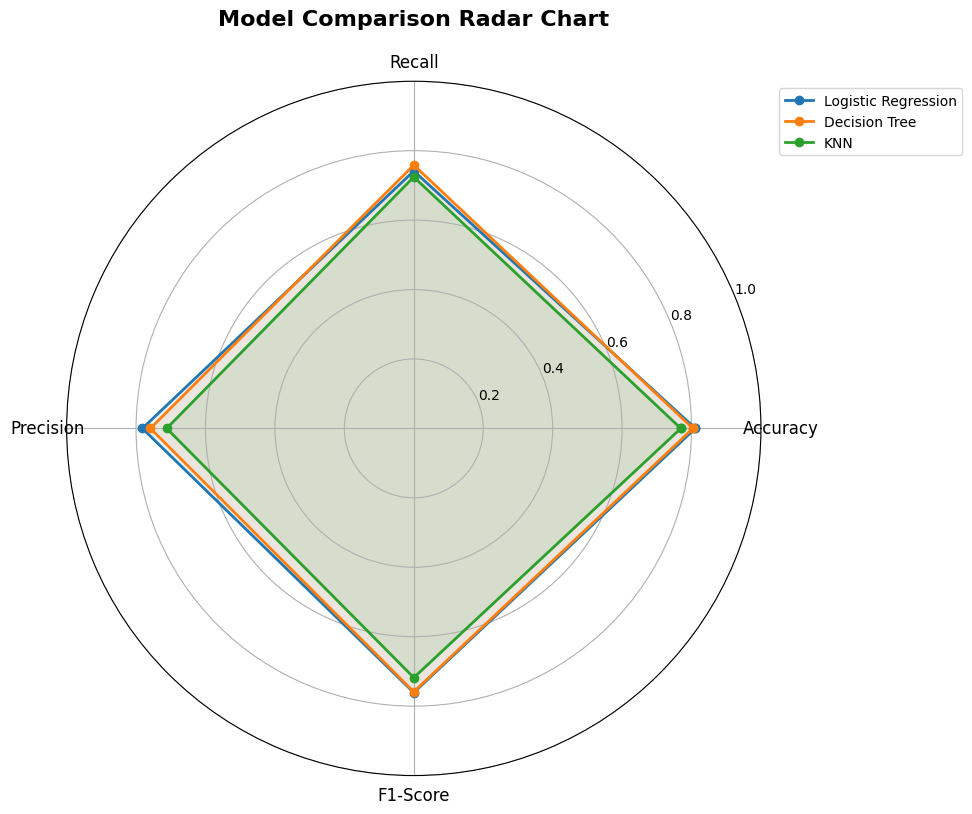

In [19]:
model_results = {}

y_pred_knn_best = best_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn_best)
knn_recall = recall_score(y_test, y_pred_knn_best)
knn_precision = precision_score(y_test, y_pred_knn_best)
knn_f1 = 2 * (knn_precision * knn_recall) / (knn_precision + knn_recall)

model_results['KNN'] = {
    'Model': best_knn,
    'Accuracy': knn_accuracy,
    'Recall': knn_recall,
    'Precision': knn_precision,
    'F1-Score': knn_f1,
    'Predictions': y_pred_knn_best,
    'Params': best_knn.get_params()
}

print(f"Best Parameters: {best_knn.get_params()}")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"F1-Score: {knn_f1:.4f}")


knn_cm = confusion_matrix(y_test, y_pred_knn_best)
print(f"Confusion Matrix:\n{knn_cm}")

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}


lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

lr_grid_search.fit(X_train_scaled, y_train)
best_lr = lr_grid_search.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_f1 = 2 * (lr_precision * lr_recall) / (lr_precision + lr_recall)

model_results['Logistic Regression'] = {
    'Model': best_lr,
    'Accuracy': lr_accuracy,
    'Recall': lr_recall,
    'Precision': lr_precision,
    'F1-Score': lr_f1,
    'Predictions': y_pred_lr,
    'Params': lr_grid_search.best_params_
}

print(f"Best Parameters: {lr_grid_search.best_params_}")
print(f"Best CV Score: {lr_grid_search.best_score_:.4f}")
print(f"Test Accuracy: {lr_accuracy:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"F1-Score: {lr_f1:.4f}")


lr_cm = confusion_matrix(y_test, y_pred_lr)
print(f"Confusion Matrix:\n{lr_cm}")


print("\nProbabilities for first 5 test samples (Logistic Regression):")
lr_probs = best_lr.predict_proba(X_test_scaled)[:5]
for i, probs in enumerate(lr_probs):
    print(f"  Sample {i+1}: Not Survived={probs[0]:.3f}, Survived={probs[1]:.3f}")

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}


dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1
)

dt_grid_search.fit(X_train, y_train)  
best_dt = dt_grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_f1 = 2 * (dt_precision * dt_recall) / (dt_precision + dt_recall)

model_results['Decision Tree'] = {
    'Model': best_dt,
    'Accuracy': dt_accuracy,
    'Recall': dt_recall,
    'Precision': dt_precision,
    'F1-Score': dt_f1,
    'Predictions': y_pred_dt,
    'Params': dt_grid_search.best_params_
}

print(f"Best Parameters: {dt_grid_search.best_params_}")
print(f"Best CV Score: {dt_grid_search.best_score_:.4f}")
print(f"Test Accuracy: {dt_accuracy:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"F1-Score: {dt_f1:.4f}")


dt_cm = confusion_matrix(y_test, y_pred_dt)
print(f"Confusion Matrix:\n{dt_cm}")


print("\nProbabilities for first 5 test samples (Decision Tree):")
dt_probs = best_dt.predict_proba(X_test)[:5]
for i, probs in enumerate(dt_probs):
    print(f"  Sample {i+1}: Not Survived={probs[0]:.3f}, Survived={probs[1]:.3f}")

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))


# plt.figure(figsize=(12, 8))
# plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15))
# plt.xlabel('Importance')
# plt.title('Top 15 Feature Importance (Decision Tree)')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['Accuracy'] for m in model_results],
    'Recall': [model_results[m]['Recall'] for m in model_results],
    'Precision': [model_results[m]['Precision'] for m in model_results],
    'F1-Score': [model_results[m]['F1-Score'] for m in model_results]
})


comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

best_by_accuracy = comparison_df.iloc[0]['Model']
best_by_recall = comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']
best_by_precision = comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']
best_by_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']

print(f"Best by Accuracy: {best_by_accuracy} ({comparison_df['Accuracy'].max():.4f})")
print(f"Best by Recall: {best_by_recall} ({comparison_df['Recall'].max():.4f})")
print(f"Best by Precision: {best_by_precision} ({comparison_df['Precision'].max():.4f})")
print(f"Best by F1-Score: {best_by_f1} ({comparison_df['F1-Score'].max():.4f})")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors[idx], alpha=0.7)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Model Performance Comparison - All Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_for_cm = ['KNN', 'Logistic Regression', 'Decision Tree']
cm_data = [knn_cm, lr_cm, dt_cm]

for idx, (model_name, cm) in enumerate(zip(models_for_cm, cm_data)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


from math import pi


categories = metrics
N = len(categories)


angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))


for idx, model_name in enumerate(comparison_df['Model']):
    values = comparison_df.loc[comparison_df['Model'] == model_name, metrics].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, marker='o')
    ax.fill(angles, values, alpha=0.1)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)


ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
ax.grid(True)


# plt.title('Model Comparison Radar Chart', fontsize=16, fontweight='bold', pad=20)
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()